In [1]:
%pip install pandas numpy requests geopandas shapely pyproj scikit-learn minisom matplotlib

Note: you may need to restart the kernel to use updated packages.


In [1]:
# ============================================================
# MRT CONTEXT ANALYSIS
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from minisom import MiniSom


# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_DIR = (
    Path.home()
    / "OneDrive"
    / "Desktop"
    / "family-toilet-search"
)

GENERATED_DIR = (
    PROJECT_DIR
    / "data"
    / "generated"
)

GENERATED_DIR.mkdir(
    parents=True,
    exist_ok=True
)


CONTEXT_FEATURES_FILE = (
    GENERATED_DIR
    / "mrt_context_features.json"
)

EXISTING_CONTEXT_FILE = (
    GENERATED_DIR
    / "mrt_context_som.json"
)

CONTEXT_OUTPUT = (
    GENERATED_DIR
    / "mrt_context_som.json"
)

SOM_IMAGE_OUTPUT = (
    GENERATED_DIR
    / "mrt_context_component_planes.png"
)


DEMOGRAPHIC_FEATURES = [

    "population_density",

    "children_percent",

    "avg_household_size",

    "hdb_percent",

    "private_housing_percent",

    "elderly_percent",

    "commercial_intensity"

]


DISPLAY_NAMES = {

    "population_density":
        "Population density",

    "children_percent":
        "Children (%)",

    "avg_household_size":
        "Average household size",

    "hdb_percent":
        "HDB (%)",

    "private_housing_percent":
        "Private housing (%)",

    "elderly_percent":
        "Elderly (%)",

    "commercial_intensity":
        "Commercial intensity"

}


print(
    PROJECT_DIR
)

C:\Users\MSI\OneDrive\Desktop\family-toilet-search


In [2]:
# ============================================================
# BUILD / LOAD CANONICAL MRT DEMOGRAPHIC DATA
# ============================================================

if CONTEXT_FEATURES_FILE.exists():

    records = json.loads(
        CONTEXT_FEATURES_FILE.read_text(
            encoding="utf-8"
        )
    )

    print(
        "Loaded canonical demographic dataset."
    )


elif EXISTING_CONTEXT_FILE.exists():

    print(
        "Creating canonical dataset from existing SOM output..."
    )


    previous_records = json.loads(
        EXISTING_CONTEXT_FILE.read_text(
            encoding="utf-8"
        )
    )


    records = []


    for old_record in previous_records:

        record = {

            "station":
                old_record.get(
                    "station"
                ),

            "lat":
                old_record.get(
                    "lat"
                ),

            "lon":
                old_record.get(
                    "lon"
                )

        }


        for feature in DEMOGRAPHIC_FEATURES:

            record[
                feature
            ] = old_record.get(
                feature
            )


        records.append(
            record
        )


    CONTEXT_FEATURES_FILE.write_text(

        json.dumps(
            records,
            indent=2
        ),

        encoding="utf-8"
    )


    print(
        "Created:",
        CONTEXT_FEATURES_FILE
    )


else:

    raise FileNotFoundError(

        "No previous MRT demographic dataset was found.\n"

        "mrt_context_som.json is required once to initialise "
        "the stable demographic dataset."

    )


# ============================================================
# DATAFRAME
# ============================================================

context_df = pd.DataFrame(
    records
)


for feature in DEMOGRAPHIC_FEATURES:

    context_df[
        feature
    ] = pd.to_numeric(

        context_df[
            feature
        ],

        errors="coerce"
    )


context_df = (

    context_df

    .dropna(
        subset=[
            "station",
            *DEMOGRAPHIC_FEATURES
        ]
    )

    .reset_index(
        drop=True
    )

)


print(
    "Usable MRTs:",
    len(
        context_df
    )
)


display(
    context_df.head()
)

Creating canonical dataset from existing SOM output...
Created: C:\Users\MSI\OneDrive\Desktop\family-toilet-search\data\generated\mrt_context_features.json
Usable MRTs: 73


,station,lat,lon,population_density,children_percent,avg_household_size,hdb_percent,private_housing_percent,elderly_percent,commercial_intensity
0,ADMIRALTY MRT,1.440407,103.800857,38763.033550,16.417458,3.472298,94.756516,5.001010,8.284502,0.093861
1,ALJUNIED MRT,1.316363,103.882485,13503.446593,11.202801,2.854086,65.141285,31.732933,19.554889,0.127992
2,ANG MO KIO MRT,1.369618,103.849676,29370.828449,11.186320,2.921147,99.643748,0.000000,21.482009,0.112329
3,BEAUTY WORLD MRT,1.341087,103.775732,7885.921443,13.580247,3.857488,24.645633,74.531321,18.381344,0.048725
4,BEDOK MRT,1.323971,103.929412,25545.754157,11.278104,3.142488,87.438905,11.999022,20.405670,0.282829


In [3]:
# ============================================================
# STANDARDISE FEATURES
# ============================================================

X = (
    context_df[
        DEMOGRAPHIC_FEATURES
    ]
    .to_numpy(
        dtype=float
    )
)


scaler = StandardScaler()


X_scaled = (
    scaler.fit_transform(
        X
    )
)


# ============================================================
# SOM SIZE
# ============================================================

n_samples = len(
    context_df
)


if n_samples < 40:

    SOM_SIZE = 5

elif n_samples < 80:

    SOM_SIZE = 7

elif n_samples < 140:

    SOM_SIZE = 9

else:

    SOM_SIZE = 11


print(
    f"SOM size: {SOM_SIZE} × {SOM_SIZE}"
)


# ============================================================
# TRAIN
# ============================================================

som = MiniSom(

    SOM_SIZE,
    SOM_SIZE,

    len(
        DEMOGRAPHIC_FEATURES
    ),

    sigma=1.5,

    learning_rate=0.4,

    neighborhood_function="gaussian",

    random_seed=42

)


som.pca_weights_init(
    X_scaled
)


iterations = max(

    5000,

    len(
        context_df
    )
    *
    100

)


som.train_random(

    X_scaled,

    iterations,

    verbose=True

)


# ============================================================
# MRT → SOM CELL
# ============================================================

positions = [

    som.winner(
        vector
    )

    for vector
    in X_scaled

]


context_df[
    "somX"
] = [

    int(
        position[0]
    )

    for position
    in positions

]


context_df[
    "somY"
] = [

    int(
        position[1]
    )

    for position
    in positions

]


context_df[
    "somCell"
] = (

    context_df[
        "somX"
    ]
    .astype(str)

    +

    "-"

    +

    context_df[
        "somY"
    ]
    .astype(str)

)


display(

    context_df[
        [
            "station",
            "somCell"
        ]
    ]
    .head(20)

)

SOM size: 7 × 7
 [ 7300 / 7300 ] 100% - 0:00:00 left 
 quantization error: 0.6179207541235943


,station,somCell
0,ADMIRALTY MRT,6-1
1,ALJUNIED MRT,2-6
2,ANG MO KIO MRT,0-4
3,BEAUTY WORLD MRT,6-5
4,BEDOK MRT,1-2
5,BEDOK NORTH MRT,2-2
6,BEDOK RESERVOIR MRT,4-4
7,BISHAN MRT,2-3
8,BOON KENG MRT,2-0
9,BOON LAY MRT,6-0


In [4]:
# ============================================================
# CONTEXT DESCRIPTOR
# ============================================================

means = (
    context_df[
        DEMOGRAPHIC_FEATURES
    ]
    .mean()
)


def describe_context(
    row
):

    labels = []


    if (
        row["population_density"]
        >
        means["population_density"]
    ):

        labels.append(
            "high-density"
        )


    if (
        row["children_percent"]
        >
        means["children_percent"]
    ):

        labels.append(
            "more-children"
        )


    if (
        row["hdb_percent"]
        >
        means["hdb_percent"]
    ):

        labels.append(
            "HDB-dominant"
        )


    if (
        row["private_housing_percent"]
        >
        means[
            "private_housing_percent"
        ]
    ):

        labels.append(
            "private-housing"
        )


    if (
        row["commercial_intensity"]
        >
        means[
            "commercial_intensity"
        ]
    ):

        labels.append(
            "commercial"
        )


    if (
        row["elderly_percent"]
        >
        means["elderly_percent"]
    ):

        labels.append(
            "ageing"
        )


    if not labels:

        return "mixed-context"


    return " / ".join(
        labels[:3]
    )


context_df[
    "contextDescriptor"
] = context_df.apply(

    describe_context,

    axis=1

)


# ============================================================
# SIMILAR MRT SEARCH
#
# calculated once here, NOT every frontend search
# ============================================================

similar_lists = []


for index in range(
    len(
        context_df
    )
):

    vector = (
        X_scaled[
            index
        ]
    )


    distances = (
        np.linalg.norm(

            X_scaled
            -
            vector,

            axis=1

        )
    )


    order = (
        np.argsort(
            distances
        )
    )


    neighbours = []


    for neighbour_index in order:

        if (
            neighbour_index
            ==
            index
        ):

            continue


        distance = float(
            distances[
                neighbour_index
            ]
        )


        similarity = (

            1

            /

            (
                1
                +
                distance
            )

        )


        row = (
            context_df.iloc[
                neighbour_index
            ]
        )


        neighbours.append({

            "station":
                row[
                    "station"
                ],

            "lat":
                row.get(
                    "lat"
                ),

            "lon":
                row.get(
                    "lon"
                ),

            "somCell":
                row[
                    "somCell"
                ],

            "contextDescriptor":
                row[
                    "contextDescriptor"
                ],

            "similarity":
                similarity

        })


        if (
            len(
                neighbours
            )
            >=
            12
        ):

            break


    similar_lists.append(
        neighbours
    )


context_df[
    "similarStations"
] = (
    similar_lists
)

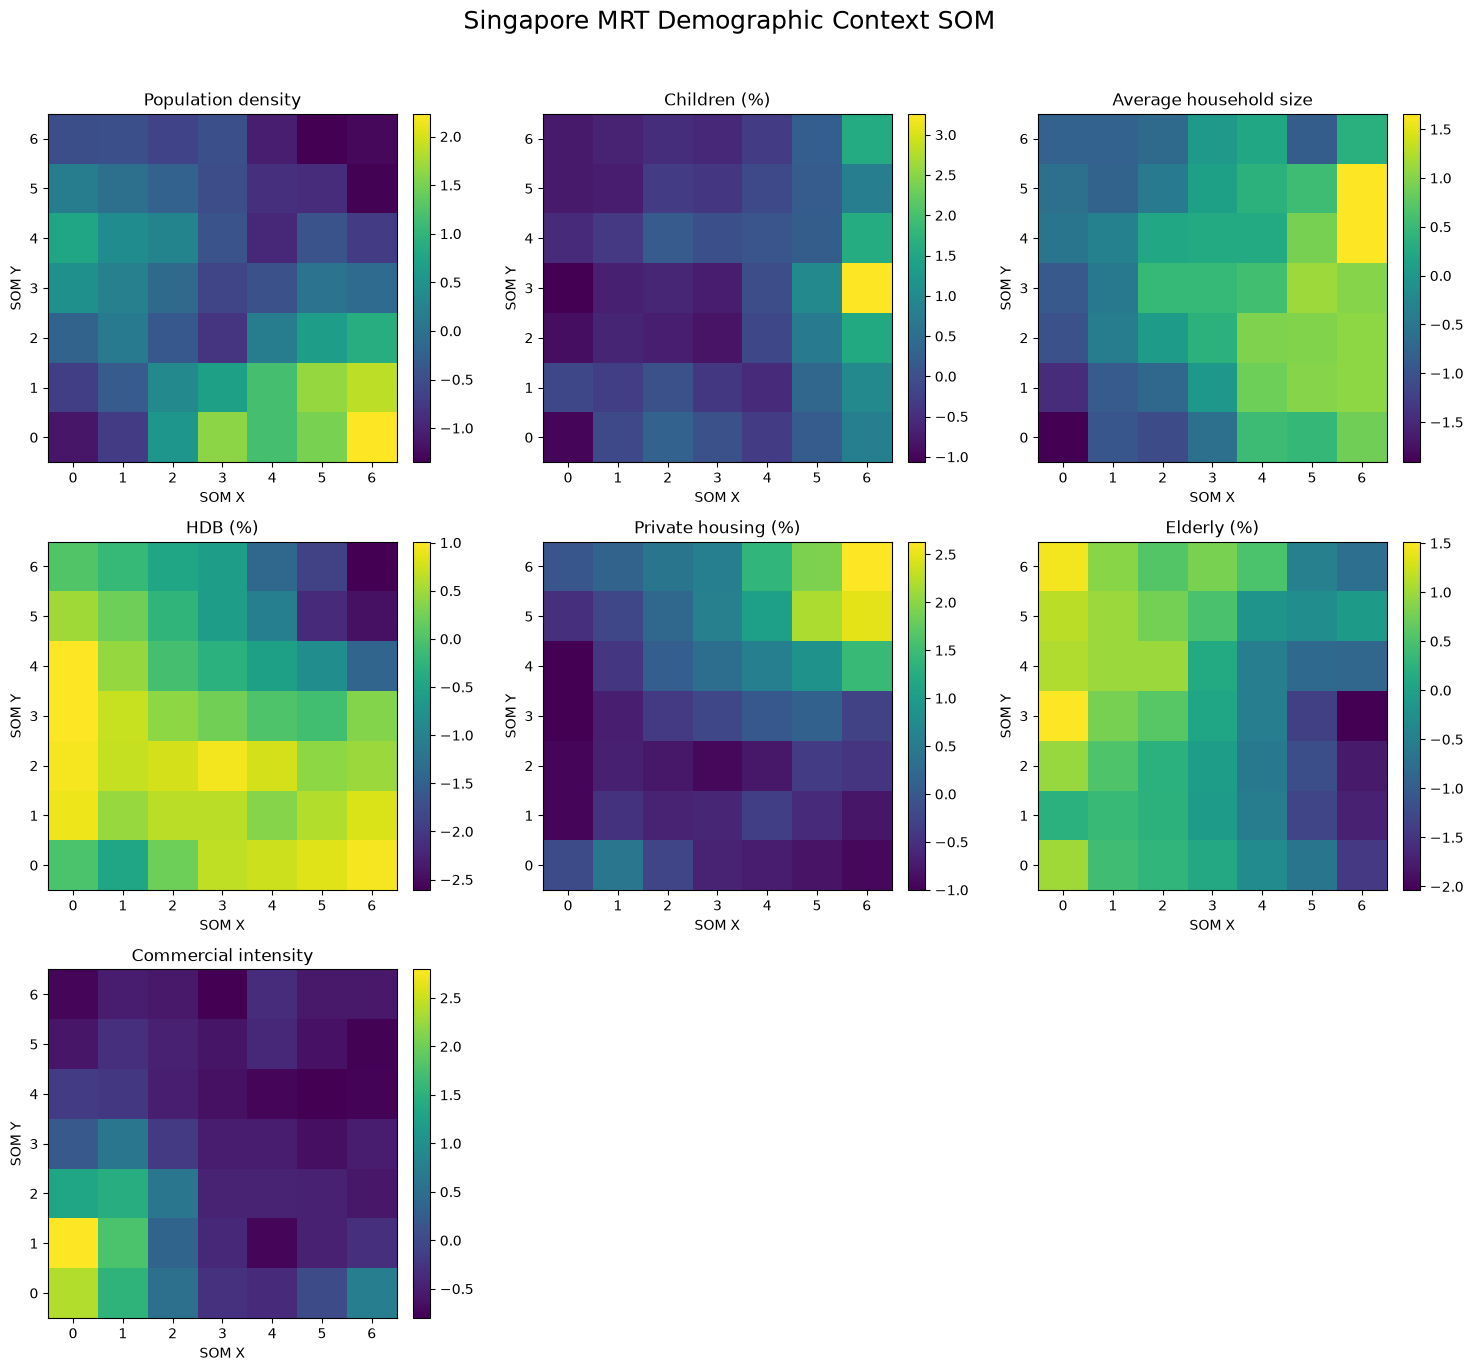

SOM image exported:
C:\Users\MSI\OneDrive\Desktop\family-toilet-search\data\generated\mrt_context_component_planes.png


In [5]:
# ============================================================
# TRUE SOM COMPONENT PLANE FIGURE
# ============================================================

weights = (
    som.get_weights()
)


feature_count = len(
    DEMOGRAPHIC_FEATURES
)


columns = 3


rows = int(
    np.ceil(
        feature_count
        /
        columns
    )
)


fig, axes = plt.subplots(

    rows,
    columns,

    figsize=(
        15,
        4.6 * rows
    )

)


axes = (
    np.array(
        axes
    )
    .reshape(-1)
)


fig.suptitle(

    "Singapore MRT Demographic Context SOM",

    fontsize=18,

    y=0.99

)


for feature_index, feature in enumerate(
    DEMOGRAPHIC_FEATURES
):

    ax = (
        axes[
            feature_index
        ]
    )


    plane = (
        weights[
            :,
            :,
            feature_index
        ]
        .T
    )


    image = ax.imshow(

        plane,

        origin="lower",

        interpolation="nearest",

        aspect="equal"

    )


    ax.set_title(

        DISPLAY_NAMES[
            feature
        ],

        fontsize=12

    )


    ax.set_xlabel(
        "SOM X"
    )


    ax.set_ylabel(
        "SOM Y"
    )


    ax.set_xticks(
        range(
            SOM_SIZE
        )
    )


    ax.set_yticks(
        range(
            SOM_SIZE
        )
    )


    fig.colorbar(

        image,

        ax=ax,

        fraction=0.046,

        pad=0.04

    )


# Hide unused plots

for index in range(
    feature_count,
    len(
        axes
    )
):

    axes[
        index
    ].axis(
        "off"
    )


plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.97
    ]
)


plt.savefig(

    SOM_IMAGE_OUTPUT,

    dpi=220,

    bbox_inches="tight"

)


plt.show()


print(
    "SOM image exported:"
)

print(
    SOM_IMAGE_OUTPUT
)

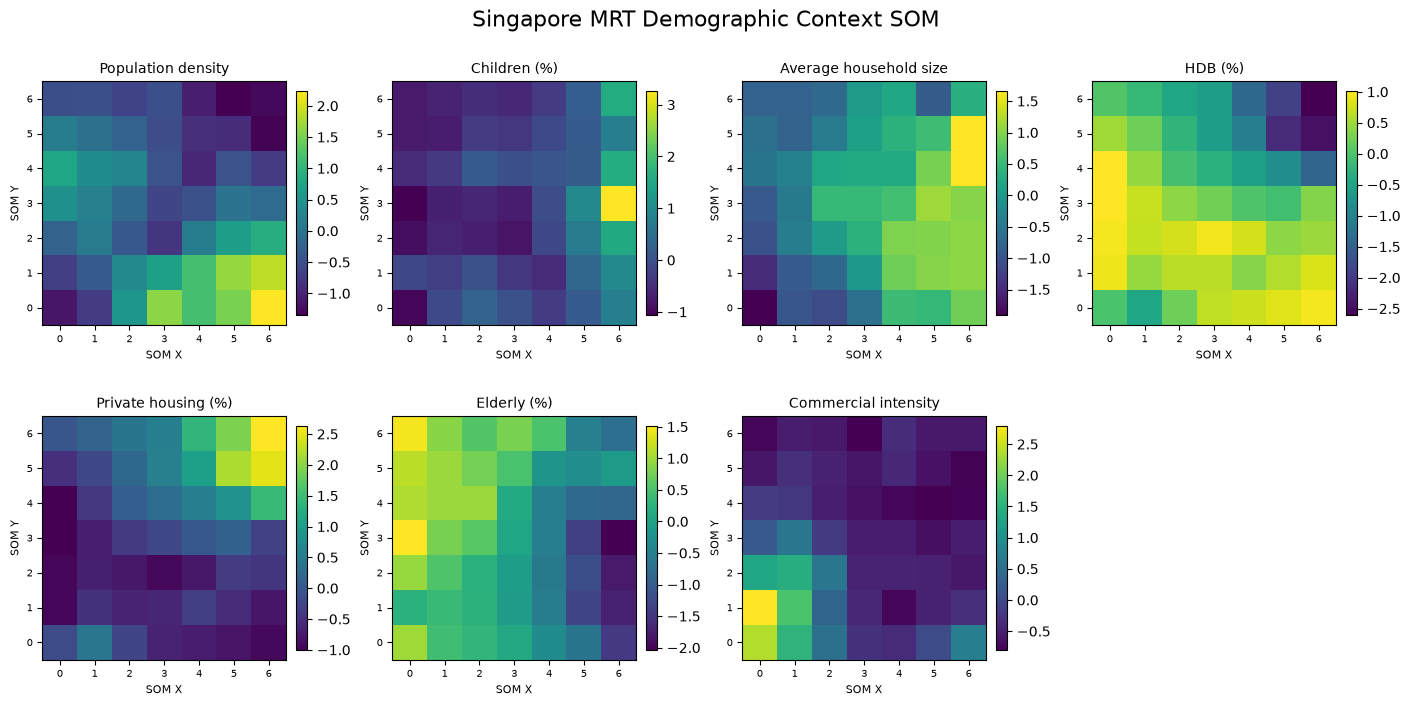

Compact SOM saved:
C:\Users\MSI\OneDrive\Desktop\family-toilet-search\data\generated\mrt_context_component_planes.png


In [6]:
# ============================================================
# COMPACT DEMOGRAPHIC SOM COMPONENT PLANES
# Frontend-ready 4 x 2 layout
# ============================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


PROJECT_DIR = (
    Path.home()
    / "OneDrive"
    / "Desktop"
    / "family-toilet-search"
)

SOM_IMAGE_OUTPUT = (
    PROJECT_DIR
    / "data"
    / "generated"
    / "mrt_context_component_planes.png"
)


DISPLAY_NAMES = {

    "population_density":
        "Population density",

    "children_percent":
        "Children (%)",

    "avg_household_size":
        "Average household size",

    "hdb_percent":
        "HDB (%)",

    "private_housing_percent":
        "Private housing (%)",

    "elderly_percent":
        "Elderly (%)",

    "commercial_intensity":
        "Commercial intensity"
}


weights = som.get_weights()


# ============================================================
# 4 columns × 2 rows
# ============================================================

fig, axes = plt.subplots(

    2,
    4,

    figsize=(14, 7),

    constrained_layout=True

)


axes = np.array(
    axes
).reshape(-1)


fig.suptitle(

    "Singapore MRT Demographic Context SOM",

    fontsize=16

)


for feature_index, feature in enumerate(
    DEMOGRAPHIC_FEATURES
):

    ax = axes[
        feature_index
    ]


    plane = (
        weights[
            :,
            :,
            feature_index
        ]
        .T
    )


    image = ax.imshow(

        plane,

        origin="lower",

        interpolation="nearest",

        aspect="equal"

    )


    ax.set_title(

        DISPLAY_NAMES[
            feature
        ],

        fontsize=10

    )


    ax.set_xlabel(
        "SOM X",
        fontsize=8
    )


    ax.set_ylabel(
        "SOM Y",
        fontsize=8
    )


    ax.tick_params(
        labelsize=7
    )


    fig.colorbar(

        image,

        ax=ax,

        fraction=0.046,

        pad=0.04

    )


# Hide final unused subplot

for index in range(
    len(DEMOGRAPHIC_FEATURES),
    len(axes)
):

    axes[
        index
    ].axis(
        "off"
    )


plt.savefig(

    SOM_IMAGE_OUTPUT,

    dpi=160,

    bbox_inches="tight",

    facecolor="white"

)


plt.show()


print(
    "Compact SOM saved:"
)

print(
    SOM_IMAGE_OUTPUT
)